In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import time

# ==========================================
# Config & Device
# ==========================================
# Mac M4 GPU (MPS)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"{DEVICE} is running")

BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 25
NUM_CLASSES = 2 

TRAIN_DIR = './dataset/train_dataset' # 400+400
TEST_DIR = './dataset/test_dataset'   # 100+100 
print(f"paths is checked")

mps is running
paths is checked


In [2]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
print(f"Images transformation has been done.")

Images transformation has been done.


In [4]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
import random
import numpy as np

print("\n>>> PyTorch Dataset Loading...")


full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=data_transforms['train'])

print(f"Original Dataset: {len(full_train_dataset)}")

targets = torch.tensor(full_train_dataset.targets)

class_0_indices = (targets == 0).nonzero(as_tuple=True)[0].tolist()
class_1_indices = (targets == 1).nonzero(as_tuple=True)[0].tolist()

print(f"  - Class 0 (Fake) in all dataset: {len(class_0_indices)}")
print(f"  - Class 1 (Original) in all dataset: {len(class_1_indices)}")

random.seed(42) 

subset_class_0 = random.sample(class_0_indices, 100)
subset_class_1 = random.sample(class_1_indices, 100)

final_indices = subset_class_0 + subset_class_1

print(f"Selected: {len(subset_class_0)} (Fake) + {len(subset_class_1)} (Original) = {len(final_indices)} ")

small_train_dataset = Subset(full_train_dataset, final_indices)

train_loader = DataLoader(small_train_dataset, batch_size=32, shuffle=True)

test_dataset = datasets.ImageFolder(TEST_DIR, transform=data_transforms['val'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


>>> PyTorch Dataset Loading...
Original Dataset: 800
  - Class 0 (Fake) in all dataset: 400
  - Class 1 (Original) in all dataset: 400
Selected: 100 (Fake) + 100 (Original) = 200 


In [5]:
class GridNetBaseline(nn.Module):
    def __init__(self):
        super(GridNetBaseline, self).__init__()
        
        # --- Block 1 ---
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2) # 224 -> 112
        self.relu = nn.ReLU()
        
        # --- Block 2 ---
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # pool: 112 -> 56
        
        # --- Block 3 (Baseline) ---
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        # pool: 56 -> 28
        
        # --- Classifier ---
        # 128 * 28 * 28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, NUM_CLASSES) 

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        
        x = x.view(x.size(0), -1) # Flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = GridNetBaseline().to(DEVICE)
print("\n>>> model is loaded in GPU")


>>> model is loaded in GPU


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_one_epoch(epoch_index):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    avg_loss = running_loss / len(train_loader)
    acc = 100 * correct / total
    return avg_loss, acc

def validate():
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_loss = running_loss / len(test_loader)
    acc = 100 * correct / total
    return avg_loss, acc

In [6]:
print(f"\n>>> Training: (Epochs: {EPOCHS})...")
train_losses, train_accs = [], []
val_losses, val_accs = [], []

start_time = time.time()

for epoch in range(EPOCHS):
    t_loss, t_acc = train_one_epoch(epoch)
    v_loss, v_acc = validate()
    
    train_losses.append(t_loss)
    train_accs.append(t_acc)
    val_losses.append(v_loss)
    val_accs.append(v_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {t_loss:.4f} Acc: {t_acc:.2f}% | "
          f"Val Loss: {v_loss:.4f} Acc: {v_acc:.2f}%")

total_time = time.time() - start_time
print(f"\n>>> Finish. Time cost: {total_time:.2f}s")


>>> Training: (Epochs: 25)...
Epoch [1/25] Train Loss: 38.0780 Acc: 53.00% | Val Loss: 10.4118 Acc: 65.50%
Epoch [2/25] Train Loss: 8.2664 Acc: 68.00% | Val Loss: 3.1117 Acc: 73.50%
Epoch [3/25] Train Loss: 4.5889 Acc: 80.00% | Val Loss: 8.5798 Acc: 73.00%
Epoch [4/25] Train Loss: 4.4503 Acc: 81.00% | Val Loss: 6.3035 Acc: 74.50%
Epoch [5/25] Train Loss: 2.7775 Acc: 84.00% | Val Loss: 2.5269 Acc: 79.00%
Epoch [6/25] Train Loss: 2.3938 Acc: 79.50% | Val Loss: 3.0770 Acc: 83.00%
Epoch [7/25] Train Loss: 2.2673 Acc: 82.00% | Val Loss: 2.5774 Acc: 83.00%
Epoch [8/25] Train Loss: 2.3026 Acc: 81.00% | Val Loss: 1.9690 Acc: 85.00%
Epoch [9/25] Train Loss: 0.9849 Acc: 84.50% | Val Loss: 3.3265 Acc: 71.50%
Epoch [10/25] Train Loss: 0.7963 Acc: 84.50% | Val Loss: 1.3204 Acc: 83.50%
Epoch [11/25] Train Loss: 0.3830 Acc: 87.00% | Val Loss: 0.5392 Acc: 90.50%
Epoch [12/25] Train Loss: 0.3806 Acc: 86.50% | Val Loss: 0.7142 Acc: 87.00%
Epoch [13/25] Train Loss: 0.2255 Acc: 90.50% | Val Loss: 0.6842 

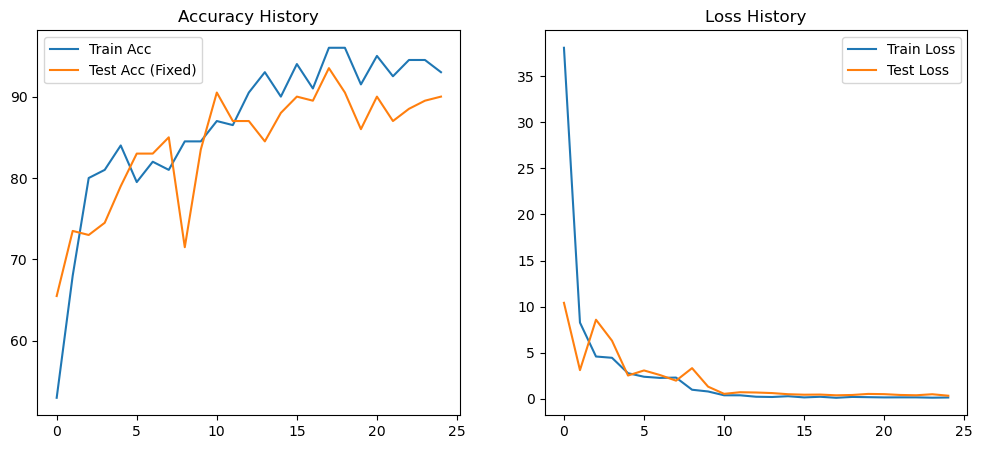

In [7]:
torch.save(model.state_dict(), '100_3depth_25epochs.pth')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Test Acc (Fixed)')
plt.title('Accuracy History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Test Loss')
plt.title('Loss History')
plt.legend()

plt.show()